# File Creater for the TOLIMAN Pupil

Install necessary packages

In [55]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import jax.numpy as np

import dLux as dl
import dLux.utils as dlu
import dLuxToliman as dlT
import src.OpticsSupport as OpticsSupport
import src.PlottingSupport as PlottingSupport
import src.STLMaker as STLMaker
import math
import scienceplots

plt.style.use(["science", "bright", "no-latex"])

cividis = mpl.colormaps["cividis"]
viridis = mpl.colormaps["viridis"]
coolwarm = mpl.colormaps["coolwarm"]

cividis.set_bad("k", 1.0)
viridis.set_bad("k", 1.0)

mpl.colors.Normalize(vmin=-1, vmax=1)


In [56]:
psf_flag = True
create_cutout = False
make_stl = False

In [57]:
# sine_image = np.load("binary/full_image_sine_small_3.npy")
# binary_image = np.load("binary/full_image_binary_small_3.npy")

# # Compute difference and center colormap at zero mean
# diff = (sine_image**0.1) - (binary_image**0.1)
# mabs = np.nanmax(np.abs(diff))

# # Save and display with symmetric color limits so mean maps to zero
# plt.imsave("binary/differences_small.pdf", diff, cmap=coolwarm, vmin=-mabs, vmax=mabs)
# plt.imshow(diff, cmap=coolwarm, vmin=-mabs, vmax=mabs)
# plt.colorbar()

# # # plt.imsave("psf_full.pdf", binary_image**0.1, cmap="inferno")


## Parameters

In [58]:
# Aperture parameters
ratio = 1  # Ratio to scale the aperture by (e.g. 5 => 5-inch aperture becomes 1-inch aperture)
aperture_npix = 5000  # Number of pixels across the aperture
aperture_diameter = 0.125 / ratio  # Clear aperture diameter (m)
secondary_diameter = 0.032 / ratio  # Secondary mirror diameter (m)
spider_width = 0.002 / ratio  # Spider width (m)

# Observations wavelegths (bandpass of 530-640nm)
wavelengths = np.linspace(530e-9, 640e-9, 3)  # Wavelengths to simulate (m)

# Substrate parameters
n1 = 1  # Refractive index of free space
# n2 = 1.5424  # Refractive index of Zerodur
n2 = 1.4828 # Refractive index of ULE @589nm

# Mask
mask_path = "diffractive_pupil.npy"
phase_mask = np.load(mask_path) * np.pi  # Load the mask and convert to phase
original_mask = np.copy(phase_mask)  # Save the original mask for later

# Grating parameters
amplitude = 421e-9 #421e-9 #300e-9 # 375e-9  # Amplitude of the grating (m). Peak to peak amplitude of the grating etched in the glass
det_npixels = 1500#4512 #3648  # DO NOT TOUCH
pixel_scale = dlu.arcsec2rad(0.4219)*ratio # dlu.arcsec2rad(0.375) * ratio  # 0.375 arcsec per pixel
#max_reach = 0.49035 #0.1465*np.sqrt(2) #0.406  # Max wavelength to diffract to 69.1443% of the diagonal length of the detector
period = (1/1.78)*1e-3

## Create the mask

In [59]:
# Make the mask
mask, raw_mask, X, Y = OpticsSupport.HelperFunctions.make_grating_mask(
    phase_mask,
    aperture_npix,
    aperture_diameter,
    secondary_diameter,
    spider_width,
    wavelengths,
    amplitude,
    det_npixels,
    pixel_scale,
    n1,
    n2,
    period,
    out=0.0,
    apply_spiders=False,
    return_raw=True,
)

Grating amplitude (nm): 421.0nm
Grating amplitude (rads): 0.6949017643928528pi rads
Grating period: 0.0005617977528089888m


In [60]:
# grating = np.load("full_grating.npy")
# anti_grating = np.load("anti_grating.npy")

# circular_mask_outer = OpticsSupport.HelperFunctions.createCircularMask(
#     aperture_npix, aperture_npix, radius=aperture_npix / 2
# )
# inner_r = (aperture_npix * (secondary_diameter / aperture_diameter)) / 2
# circular_mask_inner = 1 - OpticsSupport.HelperFunctions.createCircularMask(
#     aperture_npix, aperture_npix, radius=inner_r
# )
# circular_mask = circular_mask_outer & circular_mask_inner
# circular_mask = np.logical_and(circular_mask, raw_mask)
# circular_mask = np.where(circular_mask == 1, circular_mask, np.nan)
# circular_mask = circular_mask * grating

# print(np.max(grating))

# plt.imshow(circular_mask, cmap=cividis, vmin=0, vmax=np.max(grating))
# plt.imsave("full_grating.pdf", circular_mask, cmap=cividis)
# plt.show()

Plot mask to check correct pattern and resolution

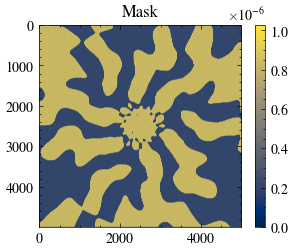

In [61]:
PlottingSupport.Plotting.printColormap(
    raw_mask, title="Mask", colorbar=True, colormap="cividis"
)


Create the phase mask and the instrument

In [62]:
wf_npixels = aperture_npix  # Number of pixels across the wavefront
peak_wavelength = np.mean(wavelengths)  # Peak wavelength of the bandpass (m)
# Create Telescope
# phase_mask = OpticsSupport.HelperFunctions.createPhaseMask(
#     raw_mask, peak_wavelength, n1, n2
# )  # Create the phase mask
# # phase_mask = np.load("5k_full_phase_pupil.npy")
# mask = dl.Optic(phase=phase_mask)
opd_mask = mask*(n2 - n1)  # Convert phase to OPD
mask = dl.Optic(opd = opd_mask)
optics = dlT.TolimanOpticalSystem(
    wf_npixels=wf_npixels, mask=mask, psf_npixels=det_npixels, oversample=1
)
print(optics)
source = dl.PointSource(wavelengths, position=(0, 0))
source = dlT.AlphaCen(n_wavels=3, separation=8, position_angle=-90)
instrument = OpticsSupport.HelperFunctions.createTolimanTelescope(
    optics, source, ratio
)
# instrument = dl.Telescope(optics, source)


TolimanOpticalSystem(
  wf_npixels=5000,
  diameter=0.125,
  layers={
    'aperture': TransmissiveLayer(transmission=f32[5000,5000], normalise=True),
    'pupil':
    Optic(opd=f32[5000,5000], phase=None, transmission=None, normalise=False)
  },
  psf_npixels=1500,
  oversample=1,
  psf_pixel_scale=0.4219
)


In [63]:

# # Build our Toliman aperture and zernike aberrations

# coords = dlu.pixel_coords(aperture_npix, aperture_diameter)
# aperture = dlu.circle(coords, 0.5 * aperture_diameter)

# # Build the optics
# optics = dl.AngularOpticalSystem(
#     wf_npixels=aperture_npix,
#     diameter=aperture_diameter,
#     layers=[
#         ("aperture", dl.layers.Optic(aperture, normalise=True)),
#         ("pupil", mask),
#     ],
#     psf_npixels=det_npixels,
#     psf_pixel_scale=0.4219,
# )
# instrument = dl.Telescope(optics, source)
# print(instrument)

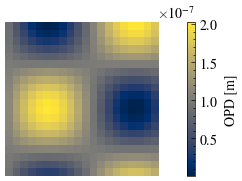

In [64]:
optics
nan_spider = np.where(
    optics.aperture.transmission == 1, optics.aperture.transmission, np.nan
)
full_aperture = nan_spider * mask.opd

fig = plt.figure(figsize=(7.2, 2))
plt.axis("off")
im = plt.imshow(full_aperture[1500:1520, 1000:1020], cmap=cividis)
cbar = fig.colorbar(im)
cbar.set_label("OPD [m]")
plt.savefig("aperture.pdf", bbox_inches="tight", dpi=3000)
plt.show()

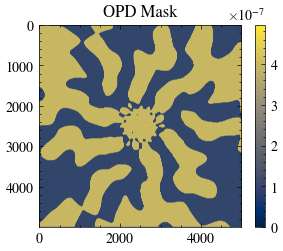

In [65]:

PlottingSupport.Plotting.printColormap(
    instrument.opd, title="OPD Mask", colorbar=True, colormap=cividis
)


Simulate the PSF

In [66]:
# Create PSF
if psf_flag:
    psf = instrument.model()

Display the PSF

150


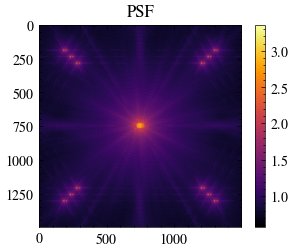

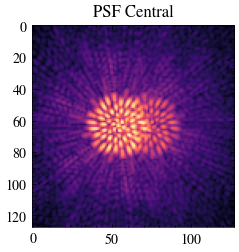

Central Flux: 68.84%


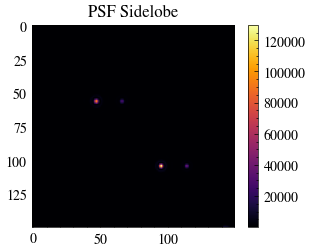

Sidelobe Flux: 15.65%
6.5751868e+07


In [67]:
if psf_flag:
    r = psf.shape[0]
    c = r // 2
    s = 64
    print(r // 10)

    central_psf = psf[c - s : c + s, c - s : c + s]
    sidelobe_psf = psf[
        math.floor(r / 11) : math.floor(r / 11) + r // 10,
        math.floor(r / 11) : math.floor(r / 11) + r // 10,
    ]
    PlottingSupport.Plotting.printColormap(
        psf**0.1, title="PSF", colorbar=True
    )
    plt.imsave("psf_full.pdf", psf**0.2, cmap="inferno")
    # plt.imsave("central_psf.pdf", central_psf, cmap="magma")
    # plt.imsave("sidelobe_psf.png", sidelobe_psf, cmap="inferno")
    PlottingSupport.Plotting.printColormap(
        central_psf**0.2, title="PSF Central", colorbar=False, colormap="magma"
    )
    np.save("full_image.npy", psf)
    plt.imsave("psf_central.pdf", central_psf**0.2, cmap="magma")
    print(f"Central Flux: {(np.sum(central_psf)/np.sum(psf))*100:.2f}%")
    PlottingSupport.Plotting.printColormap(
        sidelobe_psf, title="PSF Sidelobe", colorbar=True
    )
    print(f"Sidelobe Flux: {(np.sum(sidelobe_psf)/np.sum(psf))*4*100:.2f}%")

    print(np.sum(psf))

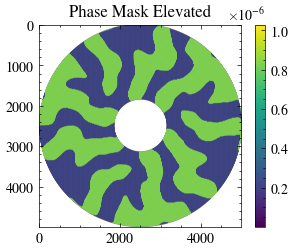

In [68]:
circular_mask_outer = OpticsSupport.HelperFunctions.createCircularMask(
    aperture_npix, aperture_npix, radius=aperture_npix / 2
)
inner_r = (aperture_npix * (secondary_diameter / aperture_diameter)) / 2
circular_mask_inner = 1 - OpticsSupport.HelperFunctions.createCircularMask(
    aperture_npix, aperture_npix, radius=inner_r
)
circular_mask = circular_mask_outer & circular_mask_inner
circular_mask = np.logical_and(circular_mask, raw_mask)
circular_mask = np.where(circular_mask == 1, circular_mask, np.nan)

circular_opd_mask = (opd_mask) * circular_mask
circular_physical_mask = (circular_opd_mask) * circular_mask*(1/(n2 - n1))

PlottingSupport.Plotting.printColormap(
    circular_physical_mask,
    title="Phase Mask Elevated",
    colorbar=True,
    colormap="viridis",
)

np.save(
    "Generated Files/Engineering/opd_mask_5k.npy",
    circular_opd_mask,
)
np.save(
    "Generated Files/Engineering/physical_mask_5k.npy",
    circular_physical_mask,
)


### Elevating the phase mask

In [69]:
# # Defining cutout areas
# x_min = int((0 / 5) * aperture_npix)
# x_max = int((0.5 / 5) * aperture_npix)
# y_low_min = int((3.6 / 5) * aperture_npix)
# y_low_max = int((4.1 / 5) * aperture_npix)
# y_high_min = int((0.5 / 5) * aperture_npix)
# y_high_max = int((1 / 5) * aperture_npix)

# # Cutout a lower section and elevate so the average is at 0.5π and 1.5π for the two steps
# cutout = phase_mask[y_low_min:y_low_max, x_min:x_max]
# PlottingSupport.Plotting.printColormap(
#     cutout, title="Cutout", colorbar=True, colormap="viridis"
# )
# cutout_mean = np.mean(cutout)
# elevation = 0.5 * np.pi - cutout_mean
# phase_mask_elevated = phase_mask + elevation
# PlottingSupport.Plotting.printColormap(
#     phase_mask_elevated,
#     title="Phase Mask Elevated",
#     colorbar=True,
#     colormap="viridis",
# )

# # Check lower section
# low_cutout_elevated = phase_mask_elevated[y_low_min:y_low_max, x_min:x_max]
# cutout_low_mean_phase = np.mean(low_cutout_elevated) / np.pi
# PlottingSupport.Plotting.printColormap(
#     low_cutout_elevated,
#     title=f"Mean Phase: {cutout_low_mean_phase:.2f}",
#     colorbar=True,
#     colormap="viridis",
# )

# if not math.isclose(0.5, cutout_low_mean_phase, rel_tol=1e-2):
#     raise Exception(f"Low cutout not at 0.5: {cutout_low_mean_phase:.5f}")

# # Check higher section
# high_cutout_elevated = phase_mask_elevated[y_high_min:y_high_max, x_min:x_max]
# cutout_high_mean_phase = np.mean(high_cutout_elevated) / np.pi
# PlottingSupport.Plotting.printColormap(
#     high_cutout_elevated,
#     title=f"Mean Phase: {cutout_high_mean_phase:.2f}",
#     colorbar=True,
#     colormap="viridis",
# )

# if not math.isclose(1.5, cutout_high_mean_phase, rel_tol=1e-2):
#     raise Exception(f"High cutout not at 1.5: {cutout_high_mean_phase:.5f}")

In [70]:
# p2p = (low_cutout_elevated.max() - low_cutout_elevated.min()) / (2 * np.pi)
# print(f"Single sinusoid p2p: {p2p: .3f}\u03c0")

Make a circular cutout

In [71]:
# scale = 0.2
# x_centre = int((4 / 5) * aperture_npix)
# y_centre = int((2.6 / 5) * aperture_npix)
# circle_cutout_region = (
#     int((4 / 5) * aperture_npix),
#     int((2.6 / 5) * aperture_npix),
# )

# if create_cutout:
#     inch_cutout = OpticsSupport.HelperFunctions.createCircularCutout(
#         scale, circle_cutout_region, aperture_npix
#     )

#     inch_cutout_elevated_phase_mask = (phase_mask + elevation) * inch_cutout
#     PlottingSupport.Plotting.printColormap(
#         inch_cutout_elevated_phase_mask,
#         title="Inch Cutout Mask",
#         colorbar=True,
#         colormap="viridis",
#     )

#     radius = int(aperture_npix * 0.2 / 2)
#     zoom = inch_cutout_elevated_phase_mask[
#         (y_centre - radius) : (y_centre + radius),
#         (x_centre - radius) : (x_centre + radius),
#     ]
#     PlottingSupport.Plotting.printColormap(
#         zoom, title="Inch Cutout Zoom", colorbar=True, colormap="viridis"
#     )

#     plt.imsave("Generated Files/Images/inch_cutout.png", zoom)
#     np.save("Generated Files/Engineering/inch_cutout.npy", zoom)

Cutout the shape of the telescope

In [72]:
circular_mask_outer = OpticsSupport.HelperFunctions.createCircularMask(
    aperture_npix, aperture_npix, radius=aperture_npix / 2
)
inner_r = (aperture_npix * (secondary_diameter / aperture_diameter)) / 2
circular_mask_inner = 1 - OpticsSupport.HelperFunctions.createCircularMask(
    aperture_npix, aperture_npix, radius=inner_r
)
circular_mask = circular_mask_outer & circular_mask_inner
circular_mask = np.logical_and(circular_mask, raw_mask)
circular_mask = np.where(circular_mask == 1, circular_mask, np.nan)

circular_elevated_phase_mask = (phase_mask + elevation) * circular_mask
# PlottingSupport.Plotting.printColormap(
#     circular_elevated_phase_mask,
#     title="Circular Elevated Phase Mask",
#     colorbar=True,
#     colormap=cividis,
# )


plt.imshow(circular_elevated_phase_mask, cmap=cividis)

conversion_factor = 125 / 5000
xticks = plt.xticks()[0]
yticks = plt.yticks()[0]


def format_mm(x, pos):
    return f"{x * conversion_factor:.0f}"


plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_mm))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_mm))

plt.xlabel("Width (mm)")
plt.ylabel("Height (mm)")
plt.colorbar(label="Phase (radians)")
plt.savefig("circular_elevated_phase_mask.pdf", dpi=2500)
plt.show()

NameError: name 'elevation' is not defined

Convert the mask to a bitmap (adding to make mean pi)

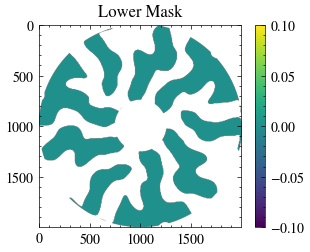

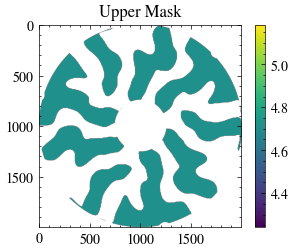

In [ ]:
modified_mask_lower = circular_elevated_phase_mask.at[
    np.where(circular_elevated_phase_mask > 3)
].set(0)

modified_mask_upper = circular_elevated_phase_mask.at[
    np.where(circular_elevated_phase_mask < 3)
].set(0)


PlottingSupport.Plotting.printColormap(
    modified_mask_lower,
    title="Lower Mask",
    colorbar=True,
    colormap="viridis",
)

PlottingSupport.Plotting.printColormap(
    modified_mask_upper,
    title="Upper Mask",
    colorbar=True,
    colormap="viridis",
)

In [ ]:
np.save(
    "Generated Files/Engineering/modified_mask_lower.npy",
    modified_mask_lower,
)
plt.imsave(
    "Generated Files/Images/modified_mask_lower.png",
    modified_mask_lower,
)

np.save(
    "Generated Files/Engineering/modified_mask_upper.npy",
    modified_mask_upper,
)
plt.imsave(
    "Generated Files/Images/modified_mask_upper.png",
    modified_mask_upper,
)

# np.save(
#     "modified_mask_lower.npy",
#     modified_mask_lower,
# )
# plt.imsave(
#     "modified_mask_lower.png",
#     modified_mask_lower,
# )

# np.save(
#     "modified_mask_upper.npy",
#     modified_mask_upper,
# )
# plt.imsave(
#     "modified_mask_upper.png",
#     modified_mask_upper,
# )

In [ ]:
np.save(
    "Generated Files/Engineering/new_diffractive_pupil.npy",
    circular_elevated_phase_mask,
)
plt.imsave(
    "Generated Files/Images/new_diffractive_pupil.png",
    circular_elevated_phase_mask,
)

In [ ]:
if make_stl == True:
    mask = circular_elevated_phase_mask
    STLMaker.Mesh2STL.mesh_to_stl(
        X,
        Y,
        mask,
        aperture_npix,
        "Generated Files/Engineering/test_file_m_25mm",
        unit_in="m",
        unit_out="m",
        binary=True,
    )
    STLMaker.Mesh2STL.mesh_to_stl(
        X,
        Y,
        mask,
        aperture_npix,
        "Generated Files/Engineering/test_file_mm_25mm",
        unit_in="m",
        unit_out="mm",
        binary=True,
    )
    STLMaker.Mesh2STL.mesh_to_stl(
        X,
        Y,
        mask,
        aperture_npix,
        "Generated Files/Engineering/test_file_um_25mm",
        unit_in="m",
        unit_out="um",
        binary=True,
    )
    STLMaker.Mesh2STL.mesh_to_stl(
        X,
        Y,
        mask,
        aperture_npix,
        "Generated Files/Engineering/test_file_nm_25mm",
        unit_in="m",
        unit_out="nm",
        binary=True,
    )